In [1]:
from sklearn.datasets import load_breast_cancer

# Load the dataset
breast_cancer_data = load_breast_cancer()

# Display the description of the dataset
print(breast_cancer_data.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [2]:
import pandas as pd

df = pd.DataFrame(data=breast_cancer_data.data, columns=breast_cancer_data.feature_names)
df['target'] = breast_cancer_data.target

display(df.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (455, 30)
Shape of X_test: (114, 30)
Shape of y_train: (455,)
Shape of y_test: (114,)


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the Logistic Regression model with an increased max_iter
log_reg_model = LogisticRegression(random_state=42, max_iter=1000)

# Train the model on scaled data
log_reg_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred = log_reg_model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.97

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [7]:
# Make predictions on the training set
y_train_pred = log_reg_model.predict(X_train_scaled)

print("Classification Report (Training Set):")
print(classification_report(y_train, y_train_pred))

print("\nClassification Report (Testing Set):")
print(classification_report(y_test, y_pred))

Classification Report (Training Set):
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       169
           1       0.99      0.99      0.99       286

    accuracy                           0.99       455
   macro avg       0.99      0.98      0.99       455
weighted avg       0.99      0.99      0.99       455


Classification Report (Testing Set):
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



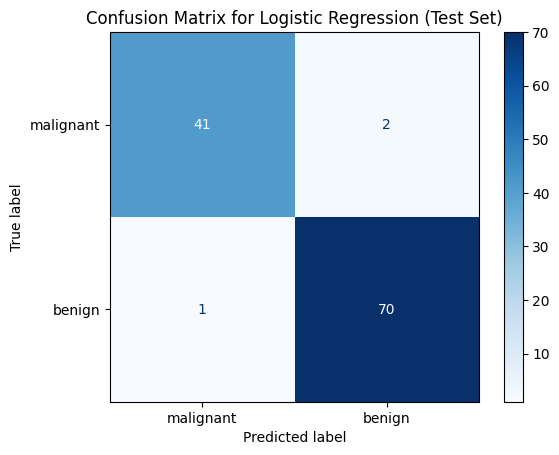

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Create the Confusion Matrix Display
cm_display = ConfusionMatrixDisplay.from_estimator(log_reg_model, X_test_scaled, y_test, cmap=plt.cm.Blues, display_labels=breast_cancer_data.target_names)

# Add a title
plt.title('Confusion Matrix for Logistic Regression (Test Set)')

# Display the plot
plt.show()

### Applying Principal Component Analysis (PCA)

PCA is a dimensionality reduction technique that transforms a large set of variables into a smaller one that still contains most of the information in the large set. This can help to reduce noise, prevent overfitting, and speed up training. We will apply PCA to our *scaled* training and testing data, aiming to retain 95% of the variance.

In [9]:
from sklearn.decomposition import PCA

# Initialize PCA to retain 95% of the variance
pca = PCA(n_components=0.95, random_state=42)

# Fit PCA on the scaled training data and transform both training and test data
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original number of features: {X_train_scaled.shape[1]}")
print(f"Number of features after PCA: {X_train_pca.shape[1]}")
print(f"Explained variance ratio by selected components: {pca.explained_variance_ratio_.sum():.2f}")
print(f"Shape of X_train_pca: {X_train_pca.shape}")
print(f"Shape of X_test_pca: {X_test_pca.shape}")

Original number of features: 30
Number of features after PCA: 10
Explained variance ratio by selected components: 0.95
Shape of X_train_pca: (455, 10)
Shape of X_test_pca: (114, 10)


### Retraining Logistic Regression with PCA-transformed Data

Now, we will train a new Logistic Regression model using the reduced feature set obtained from PCA. We will then evaluate its performance using classification reports for both the training and testing sets.

In [10]:
# Initialize a new Logistic Regression model with increased max_iter
log_reg_model_pca = LogisticRegression(random_state=42, max_iter=1000)

# Train the model on PCA-transformed data
log_reg_model_pca.fit(X_train_pca, y_train)

# Make predictions on the PCA-transformed training set
y_train_pred_pca = log_reg_model_pca.predict(X_train_pca)

# Make predictions on the PCA-transformed test set
y_pred_pca = log_reg_model_pca.predict(X_test_pca)

print("Classification Report (Training Set after PCA):")
print(classification_report(y_train, y_train_pred_pca))

print("\nClassification Report (Testing Set after PCA):")
print(classification_report(y_test, y_pred_pca))

Classification Report (Training Set after PCA):
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       169
           1       0.98      0.99      0.99       286

    accuracy                           0.98       455
   macro avg       0.99      0.98      0.98       455
weighted avg       0.98      0.98      0.98       455


Classification Report (Testing Set after PCA):
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        43
           1       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



### Visualizing the Confusion Matrix for PCA-transformed Data

Finally, let's visualize the confusion matrix for the Logistic Regression model trained with PCA-transformed data on the test set. This will help us understand the types of errors the model is making.

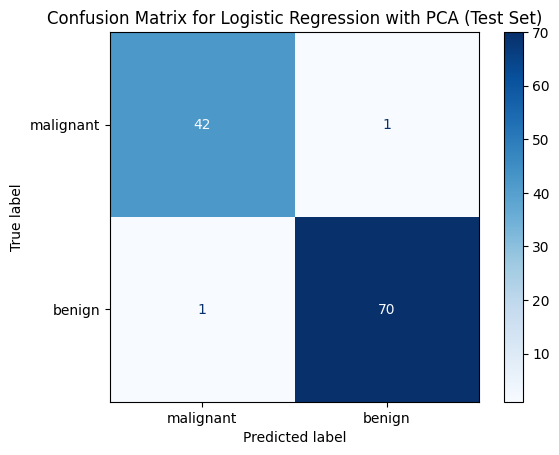

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Create the Confusion Matrix Display for PCA-transformed data
cm_display_pca = ConfusionMatrixDisplay.from_estimator(log_reg_model_pca, X_test_pca, y_test, cmap=plt.cm.Blues, display_labels=breast_cancer_data.target_names)

# Add a title
plt.title('Confusion Matrix for Logistic Regression with PCA (Test Set)')

# Display the plot
plt.show()

### Optimizing PCA Components with Grid Search

To find the best number of components for PCA, we'll use `GridSearchCV` with a pipeline. The pipeline will first scale the data (`StandardScaler`), then apply PCA (`PCA`), and finally train a Logistic Regression model (`LogisticRegression`). We will search for the optimal `n_components` for PCA in the range of 5 to 15.

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create a pipeline with StandardScaler, PCA, and Logistic Regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(random_state=42)),
    ('log_reg', LogisticRegression(random_state=42, max_iter=1000))
])

# Define the parameter grid for PCA components
param_grid = {
    'pca__n_components': range(5, 16) # Test n_components from 5 to 15
}

# Initialize GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit Grid Search to the original (unscaled) training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.2f}")

Fitting 5 folds for each of 11 candidates, totalling 55 fits
Best parameters found: {'pca__n_components': 15}
Best cross-validation accuracy: 0.98


### Evaluating the Best Model from Grid Search

Now that we have found the best PCA components, let's evaluate the performance of this optimized model on the test set and visualize its confusion matrix.

In [13]:
# Get the best estimator (the pipeline with optimal PCA components and Logistic Regression)
best_model = grid_search.best_estimator_

# Make predictions on the test set using the best model
y_pred_optimized = best_model.predict(X_test)

# Print the classification report for the optimized model
print("Classification Report (Optimized Model with PCA - Test Set):")
print(classification_report(y_test, y_pred_optimized))

# Make predictions on the training set using the best model
y_train_pred_optimized = best_model.predict(X_train)

# Print the classification report for the optimized model on the training set
print("\nClassification Report (Optimized Model with PCA - Training Set):")
print(classification_report(y_train, y_train_pred_optimized))

Classification Report (Optimized Model with PCA - Test Set):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        43
           1       0.99      1.00      0.99        71

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114


Classification Report (Optimized Model with PCA - Training Set):
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       169
           1       0.99      0.99      0.99       286

    accuracy                           0.99       455
   macro avg       0.99      0.98      0.99       455
weighted avg       0.99      0.99      0.99       455



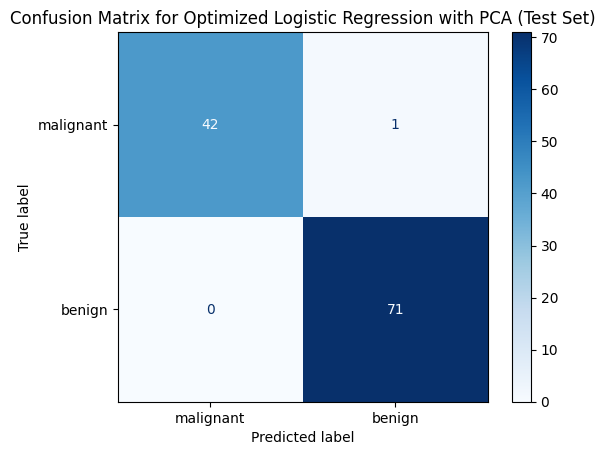

In [14]:
# Visualize the Confusion Matrix for the optimized model on the test set
cm_display_optimized = ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, cmap=plt.cm.Blues, display_labels=breast_cancer_data.target_names)

plt.title('Confusion Matrix for Optimized Logistic Regression with PCA (Test Set)')
plt.show()